# Ingestion QC

Read-only проверка BIDS одного датасета. Датасет выбирается в `DATASET`, всё
остальное общее. Ничего не пишет; найденное чинится в `src/`.

In [1]:
from pathlib import Path

import mne
import pandas as pd
from mne_bids import find_matching_paths, get_entity_vals, print_dir_tree, read_raw_bids

# Импорт стандартизации — заодно проверка, что модуль собран в .venv.
from dataset_standardization import standardize_distinguishing, standardize_sam40

%matplotlib inline
mne.viz.set_browser_backend("matplotlib")
mne.set_log_level("ERROR")
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 80)

DATASET = "sam40"  # "sam40" | "distinguishing"
SAMPLE = 0  # индекс записи для визуальной проверки

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
BIDS_ROOT = PROJECT_ROOT / "datasets" / "bids" / DATASET

print(f"{BIDS_ROOT}  exists={BIDS_ROOT.is_dir()}")
print(f"standardization: {[f.__name__ for f in (standardize_sam40, standardize_distinguishing)]}")

Using matplotlib as 2D backend.


/home/datalake/models_test/python_project/datasets/bids/sam40  exists=True
standardization: ['standardize_sam40', 'standardize_distinguishing']


/home/datalake/models_test/python_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Раскладка и entities

In [2]:
print_dir_tree(BIDS_ROOT, max_depth=1)
print_dir_tree(sorted(BIDS_ROOT.glob("sub-*"))[0], max_depth=3)

|sam40/
|--- CHANGES
|--- README
|--- dataset_description.json
|--- participants.json
|--- participants.tsv
|--- sub-01/
|--- sub-02/
|--- sub-03/
|--- sub-04/
|--- sub-05/
|--- sub-06/
|--- sub-07/
|--- sub-08/
|--- sub-09/
|--- sub-10/
|--- sub-11/
|--- sub-12/
|--- sub-13/
|--- sub-14/
|--- sub-15/
|--- sub-16/
|--- sub-17/
|--- sub-18/
|--- sub-19/
|--- sub-20/
|--- sub-21/
|--- sub-22/
|--- sub-23/
|--- sub-24/
|--- sub-25/
|--- sub-26/
|--- sub-27/
|--- sub-28/
|--- sub-29/
|--- sub-30/
|--- sub-31/
|--- sub-32/
|--- sub-33/
|--- sub-34/
|--- sub-35/
|--- sub-36/
|--- sub-37/
|--- sub-38/
|--- sub-39/
|--- sub-40/
|sub-01/
|--- sub-01_scans.json
|--- sub-01_scans.tsv
|--- eeg/
|------ sub-01_space-CapTrak_coordsystem.json
|------ sub-01_space-CapTrak_electrodes.json
|------ sub-01_space-CapTrak_electrodes.tsv
|------ sub-01_task-arithmetic_run-01_channels.tsv
|------ sub-01_task-arithmetic_run-01_eeg.eeg
|------ sub-01_task-arithmetic_run-01_eeg.json
|------ sub-01_task-arithmeti

In [3]:
entities = {name: get_entity_vals(BIDS_ROOT, name) for name in ("subject", "session", "task", "run")}
for name, values in entities.items():
    print(f"{name:8s} {len(values):4d}  {values[:8]}{' ...' if len(values) > 8 else ''}")

# ICA-юнит Stage 1 — это (subject, session, run), где неиспользуемая entity
# равна None: у Distinguishing это подтверждённая сессия, у SAM40 — повтор
# протокола. Здесь просто видно, какими entity датасет его выражает.
print(f"\nunit entities: {[n for n in ('session', 'run') if entities[n]]}")

subject    40  ['01', '02', '03', '04', '05', '06', '07', '08'] ...
session     0  []
task        4  ['arithmetic', 'mirror', 'relax', 'stroop']
run         3  ['01', '02', '03']

unit entities: ['run']


In [4]:
for name in ("dataset_description.json", "README", "CHANGES"):
    path = BIDS_ROOT / name
    print(f"\n===== {name} ({'ok' if path.exists() else 'MISSING'}) =====")
    if path.exists():
        print(path.read_text(encoding="utf-8").strip()[:1200])


===== dataset_description.json (ok) =====
{
    "Name": "SAM 40 EEG stress-task dataset",
    "BIDSVersion": "1.9.0",
    "DatasetType": "raw",
    "Authors": [
        "Rajdeep Ghosh",
        "Nabamita Deb",
        "Kaushik Sengupta"
    ],
    "ReferencesAndLinks": [
        "https://figshare.com/articles/dataset/SAM_40_Dataset_of_40_Subject_EEG_Recordings_to_Monitor_the_Induced-Stress_while_performing_Stroop_Color-Word_Test_Arithmetic_Task_and_Mirror_Image_Recognition_Task/14562090"
    ],
    "Keywords": [
        "EEG",
        "stress",
        "Stroop",
        "arithmetic"
    ],
    "GeneratedBy": [
        {
            "Name": "MNE-BIDS",
            "Version": "0.19.0",
            "CodeURL": "https://mne.tools/mne-bids/"
        }
    ]
}

===== README (ok) =====
References
----------
Appelhoff, S., Sanderson, M., Brooks, T., Vliet, M., Quentin, R., Holdgraf, C., Chaumon, M., Mikulan, E., Tavabi, K., Höchenberger, R., Welke, D., Brunner, C., Rockhill, A., Larson, E., Gr

In [5]:
participants = pd.read_csv(BIDS_ROOT / "participants.tsv", sep="\t", dtype=str)
print(f"participants.tsv: {participants.shape}, subjects on disk: {len(entities['subject'])}")
participants

participants.tsv: (40, 6), subjects on disk: 40


,participant_id,age,sex,hand,weight,height
0,sub-01,NaN,NaN,NaN,NaN,NaN
1,sub-02,NaN,NaN,NaN,NaN,NaN
2,sub-03,NaN,NaN,NaN,NaN,NaN
3,sub-04,NaN,NaN,NaN,NaN,NaN
4,sub-05,NaN,NaN,NaN,NaN,NaN
5,sub-06,NaN,NaN,NaN,NaN,NaN
6,sub-07,NaN,NaN,NaN,NaN,NaN
7,sub-08,NaN,NaN,NaN,NaN,NaN
8,sub-09,NaN,NaN,NaN,NaN,NaN
9,sub-10,NaN,NaN,NaN,NaN,NaN


## Inventory

In [6]:
paths = find_matching_paths(BIDS_ROOT, datatypes="eeg", extensions=".vhdr")
inventory = pd.DataFrame(
    [{"subject": p.subject, "session": p.session, "run": p.run, "task": p.task,
      "file": str(p.fpath.relative_to(BIDS_ROOT))} for p in paths]
).sort_values(["subject", "session", "run", "task"], ignore_index=True)

# Тот же ключ, по которому Stage 1 группирует ICA-юниты.
unit = ["subject", "session", "run"]
print(f"recordings: {len(inventory)}")
print(f"per subject: {sorted(inventory.groupby('subject').size().unique())}")
print(f"per unit: {sorted(inventory.groupby(unit, dropna=False).size().unique())}")
duplicates = inventory[inventory.duplicated(unit + ["task"], keep=False)]
print(f"duplicate subject/session/run/task: {len(duplicates)}")
inventory.pivot_table(index="subject", columns=["session", "run", "task"], values="file",
                      aggfunc="count", fill_value=0, dropna=False)

recordings: 480
per subject: [np.int64(12)]
per unit: [np.int64(4)]
duplicate subject/session/run/task: 0


session        NaN                                                                                  
run             01                             02                             03                    
task    arithmetic mirror relax stroop arithmetic mirror relax stroop arithmetic mirror relax stroop
subject                                                                                             
01               1      1     1      1          1      1     1      1          1      1     1      1
02               1      1     1      1          1      1     1      1          1      1     1      1
03               1      1     1      1          1      1     1      1          1      1     1      1
04               1      1     1      1          1      1     1      1          1      1     1      1
05               1      1     1      1          1      1     1      1          1      1     1      1
06               1      1     1      1          1      1     1      1          1      1     1      1
07               1      1     1      1          1      1     1      1          1      1     1      1
08               1      1     1      1          1      1     1      1          1      1     1      1
09               1      1     1      1          1      1     1      1          1      1     1      1
10               1      1     1      1          1      1     1      1          1      1     1      1
11               1      1     1      1          1      1     1      1          1      1     1      1
12               1      1     1      1          1      1     1      1          1      1     1      1
13               1      1     1      1          1      1     1      1          1      1     1      1
14               1      1     1      1          1      1     1      1          1      1     1      1
15               1      1     1      1          1      1     1      1          1      1     1      1
16               1      1     1      1          1      1     1      1          1      1     1      1
17               1      1     1      1          1      1     1      1          1      1     1      1
18               1      1     1      1          1      1     1      1          1      1     1      1
19               1      1     1      1          1      1     1      1          1      1     1      1
20               1      1     1      1          1      1     1      1          1      1     1      1
21               1      1     1      1          1      1     1      1          1      1     1      1
22               1      1     1      1          1      1     1      1          1      1     1      1
23               1      1     1      1          1      1     1      1          1      1     1      1
24               1      1     1      1          1      1     1      1          1      1     1      1
25               1      1     1      1          1      1     1      1          1      1     1      1
26               1      1     1      1          1      1     1      1          1      1     1      1
27               1      1     1      1          1      1     1      1          1      1     1      1
28               1      1     1      1          1      1     1      1          1      1     1      1
29               1      1     1      1          1      1     1      1          1      1     1      1
30               1      1     1      1          1      1     1      1          1      1     1      1
31               1      1     1      1          1      1     1      1          1      1     1      1
32               1      1     1      1          1      1     1      1          1      1     1      1
33               1      1     1      1          1      1     1      1          1      1     1      1
34               1      1     1      1          1      1     1      1          1      1     1      1
35               1      1     1      1          1      1     1      1          1      1     1      1
36               1      1     1      1          1      1     

In [7]:
# sessions.tsv существует только у датасета с подтверждёнными source sessions.
# Его отсутствие у SAM40 — не пробел в метаданных, а отсутствие самого понятия,
# поэтому здесь это ожидаемая ветка, а не ошибка.
sessions_paths = sorted(BIDS_ROOT.glob("sub-*/sub-*_sessions.tsv"))
if sessions_paths:
    sessions_meta = pd.concat(
        [pd.read_csv(p, sep="\t", dtype=str).assign(subject=p.parent.name.removeprefix("sub-"))
         for p in sessions_paths],
        ignore_index=True,
    )
    print(f"sessions.tsv rows: {len(sessions_meta)}")
    for column in sessions_meta.columns.drop(["session_id", "subject"], errors="ignore"):
        print(f"  {column}: {sessions_meta[column].value_counts().to_dict()}")
else:
    sessions_meta = None
    print("sessions.tsv: нет — у источника нет sessions (ожидаемо для SAM40)")

# Глубина пути до scans.tsv различается вместе с наличием ses-*, поэтому glob
# рекурсивный, а subject берётся из имени самого файла, а не из позиции папки.
scans_meta = pd.concat(
    [pd.read_csv(p, sep="\t", dtype=str).assign(subject=p.name.split("_")[0].removeprefix("sub-"))
     for p in sorted(BIDS_ROOT.glob("sub-*/**/sub-*_scans.tsv"))],
    ignore_index=True,
)
required_scans_columns = {"filename", "acq_time", "source"}
missing_scans_columns = required_scans_columns - set(scans_meta.columns)
if missing_scans_columns or scans_meta["source"].isna().any() or (scans_meta["source"] == "n/a").any():
    raise ValueError(f"Broken scans provenance: missing columns {sorted(missing_scans_columns)}")
print(f"scans.tsv rows: {len(scans_meta)}, sources: {scans_meta['source'].nunique()}")
sessions_meta, scans_meta

sessions.tsv: нет — у источника нет sessions (ожидаемо для SAM40)


scans.tsv rows: 480, sources: 480


(None,
                                        filename acq_time                         source subject
 0    eeg/sub-01_task-arithmetic_run-01_eeg.vhdr      NaN    Arithmetic_sub_1_trial1.mat      01
 1    eeg/sub-01_task-arithmetic_run-02_eeg.vhdr      NaN    Arithmetic_sub_1_trial2.mat      01
 2    eeg/sub-01_task-arithmetic_run-03_eeg.vhdr      NaN    Arithmetic_sub_1_trial3.mat      01
 3        eeg/sub-01_task-mirror_run-01_eeg.vhdr      NaN  Mirror_image_sub_1_trial1.mat      01
 4        eeg/sub-01_task-mirror_run-02_eeg.vhdr      NaN  Mirror_image_sub_1_trial2.mat      01
 ..                                          ...      ...                            ...     ...
 475       eeg/sub-40_task-relax_run-02_eeg.vhdr      NaN        Relax_sub_40_trial2.mat      40
 476       eeg/sub-40_task-relax_run-03_eeg.vhdr      NaN        Relax_sub_40_trial3.mat      40
 477      eeg/sub-40_task-stroop_run-01_eeg.vhdr      NaN       Stroop_sub_40_trial1.mat      40
 478      eeg/sub-40_ta

## Содержимое записей

In [8]:
records, errors, blocks = [], [], []
for path in paths:
    try:
        raw = read_raw_bids(path, verbose="ERROR")
    except Exception as exc:  # собрать все нечитаемые файлы, а не упасть на первом
        errors.append({"file": str(path.fpath.relative_to(BIDS_ROOT)), "error": str(exc)})
        continue
    blocks += [{"subject": path.subject, "session": path.session, "run": path.run,
                "task": path.task, "description": description, "onset": onset, "duration": duration}
               for description, onset, duration in zip(
                   raw.annotations.description, raw.annotations.onset, raw.annotations.duration)]
    records.append({
        "subject": path.subject, "session": path.session, "run": path.run, "task": path.task,
        "sfreq": raw.info["sfreq"], "n_channels": len(raw.ch_names), "ch_names": tuple(raw.ch_names),
        "duration_s": raw.n_times / raw.info["sfreq"], "montage": raw.get_montage() is not None,
        "n_annotations": len(raw.annotations), "highpass": raw.info["highpass"], "lowpass": raw.info["lowpass"],
    })
qc = pd.DataFrame(records)

print(f"read: {len(qc)}/{len(paths)}, errors: {len(errors)}")
print(f"sfreq: {qc['sfreq'].unique()}")
print(f"n_channels: {qc['n_channels'].unique()}, distinct channel sets: {qc['ch_names'].nunique()}")
print(f"channels: {list(qc['ch_names'].iloc[0])}")
print(f"montage present: {qc['montage'].sum()}/{len(qc)}")
print(f"duration_s: min={qc['duration_s'].min():.2f} max={qc['duration_s'].max():.2f}")
print(f"annotations per recording: {sorted(qc['n_annotations'].unique())}")
pd.DataFrame(errors) if errors else qc.drop(columns="ch_names").head()

read: 480/480, errors: 0
sfreq: [128.]
n_channels: [32], distinct channel sets: 1
channels: ['CZ', 'FZ', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'PZ', 'OZ', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
montage present: 480/480
duration_s: min=25.00 max=25.00
annotations per recording: [np.int64(1)]


,subject,session,run,task,sfreq,n_channels,duration_s,montage,n_annotations,highpass,lowpass
0,01,None,01,arithmetic,128.0,32,25.0,True,1,0.0,64.0
1,01,None,02,arithmetic,128.0,32,25.0,True,1,0.0,64.0
2,01,None,03,arithmetic,128.0,32,25.0,True,1,0.0,64.0
3,01,None,01,mirror,128.0,32,25.0,True,1,0.0,64.0
4,01,None,02,mirror,128.0,32,25.0,True,1,0.0,64.0


In [9]:
annotations = pd.DataFrame(blocks)
print(annotations.groupby("description")[["onset", "duration"]].agg(["count", "min", "max"]))
label_sets = annotations.groupby(["subject", "session", "run", "task"], dropna=False)["description"].apply(frozenset)
print(f"\nblock label sets per recording: {label_sets.value_counts().to_dict()}")
annotations.head(12)

            onset           duration            
            count  min  max    count   min   max
description                                     
arithmetic    120  0.0  0.0      120  25.0  25.0
mirror        120  0.0  0.0      120  25.0  25.0
relax         120  0.0  0.0      120  25.0  25.0
stroop        120  0.0  0.0      120  25.0  25.0

block label sets per recording: {frozenset({np.str_('arithmetic')}): 120, frozenset({np.str_('mirror')}): 120, frozenset({np.str_('relax')}): 120, frozenset({np.str_('stroop')}): 120}


,subject,session,run,task,description,onset,duration
0,01,None,01,arithmetic,arithmetic,0.0,25.0
1,01,None,02,arithmetic,arithmetic,0.0,25.0
2,01,None,03,arithmetic,arithmetic,0.0,25.0
3,01,None,01,mirror,mirror,0.0,25.0
4,01,None,02,mirror,mirror,0.0,25.0
5,01,None,03,mirror,mirror,0.0,25.0
6,01,None,01,relax,relax,0.0,25.0
7,01,None,02,relax,relax,0.0,25.0
8,01,None,03,relax,relax,0.0,25.0
9,01,None,01,stroop,stroop,0.0,25.0


## Визуальная проверка

sub-01/eeg/sub-01_task-arithmetic_run-01_eeg.vhdr
<Info | 10 non-empty values
 bads: []
 ch_names: CZ, FZ, Fp1, F7, F3, FC1, C3, FC5, FT9, T7, CP5, CP1, P3, P7, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 128.0 Hz
 subject_info: <subject_info | his_id: sub-01, sex: 0, hand: 0>
>


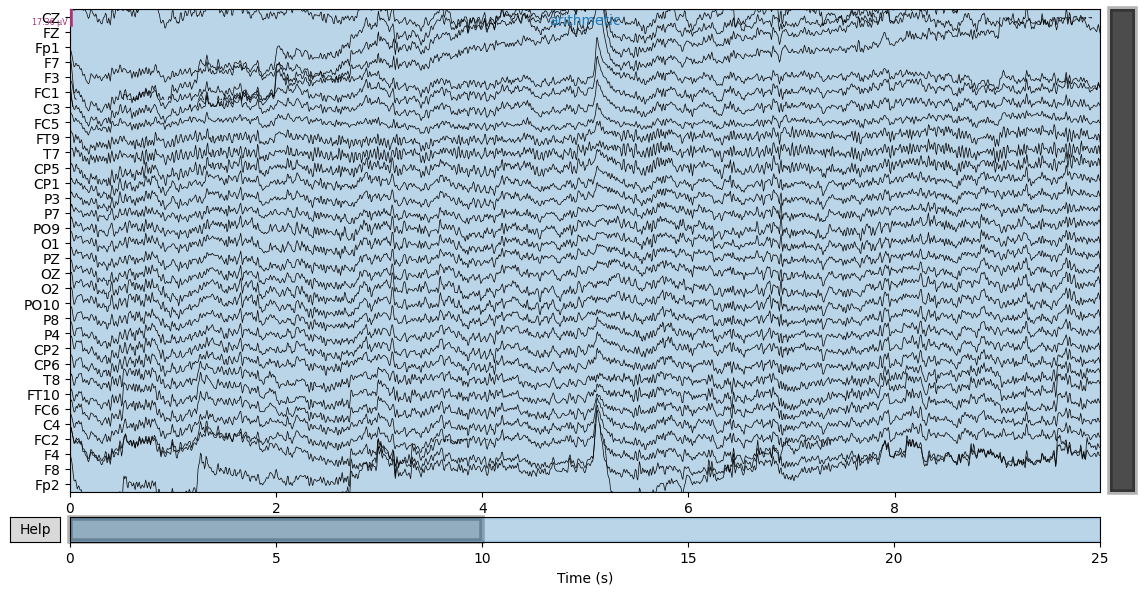

In [10]:
sample = paths[SAMPLE]
raw = read_raw_bids(sample, verbose="ERROR").load_data()
print(sample.fpath.relative_to(BIDS_ROOT))
print(raw.info)

fig = raw.plot(duration=10.0, n_channels=len(raw.ch_names), scalings="auto", show=False,
               title=str(sample.fpath.name))
fig.set_size_inches(12, 6)

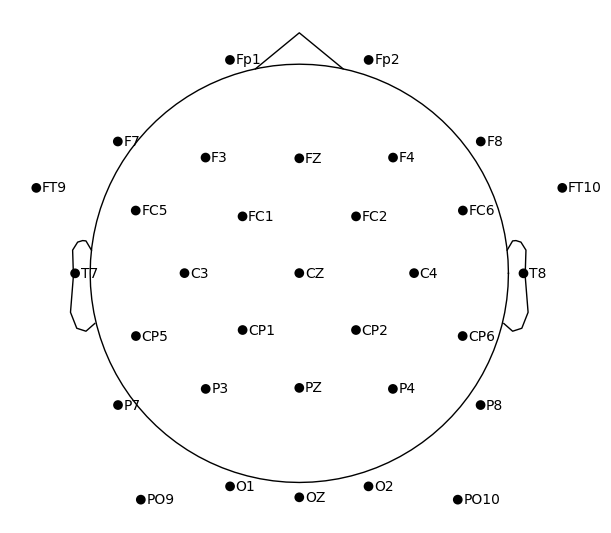

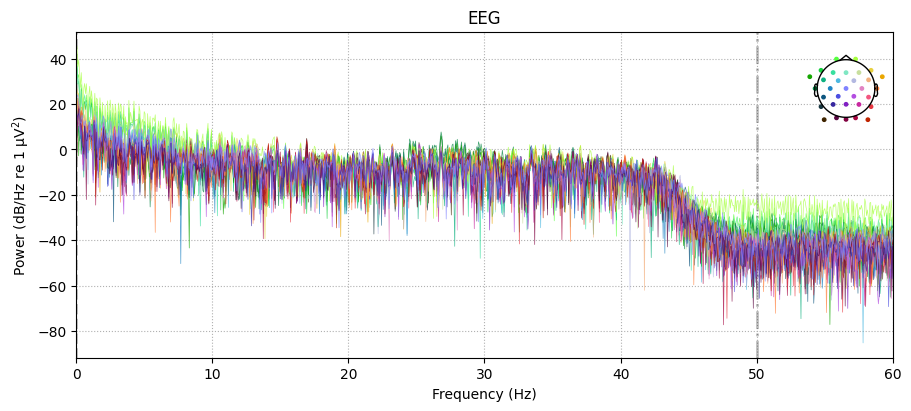

In [11]:
fig = raw.plot_sensors(show_names=True, show=False)
fig.set_size_inches(6, 6)

fig = raw.compute_psd(fmax=raw.info["sfreq"] / 2 - 4.0, verbose="ERROR").plot(show=False)
fig.set_size_inches(9, 4)